<a href="https://colab.research.google.com/github/NickBoivinSlu/ores5160-2026/blob/main/Boivin_week9assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Q1. Reading the CSV File (pandas + csv)




```
# This is formatted as code
```


Q1. Reading the CSV File (pandas + csv)

	1.	Use the csv module to open and print the first 5 rows of est2018-pop-res.csv.

	2.	Then use pandas.read_csv() to load the same file into a DataFrame.

	•	Display the shape (rows × columns).

	•	Print the list of column names.

	3.	Which column represents total population? Display the top 5 most populous states


###1.  Use the csv module to open and print the first 5 rows of est2018-pop-res.csv.


In [67]:
import pandas as pd
df = pd.read_csv('est2018-pop-res.csv')
df.head()

,SUMLEV,REGION,DIVISION,STATE,NAME,POPESTIMATE2018,POPEST18PLUS2018,PCNT_POPEST18PLUS
0,10,0,0,0,United States,327167434,253768092,77.6
1,40,3,6,1,Alabama,4887871,3798031,77.7
2,40,4,9,2,Alaska,737438,553622,75.1
3,40,4,8,4,Arizona,7171646,5528989,77.1
4,40,3,7,5,Arkansas,3013825,2310645,76.7


### 2.  Then use pandas.read_csv() to load the same file into a DataFrame.


####Display the shape (rows × columns).

In [68]:
df.shape

(53, 8)

#### Print the list of column names.

In [69]:
df.columns

Index(['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018',
       'POPEST18PLUS2018', 'PCNT_POPEST18PLUS'],
      dtype='object')

###3.  Which column represents total population? Display the top 5 most populous states


In [70]:
df.sort_values('POPESTIMATE2018', ascending = False).head(6)

,SUMLEV,REGION,DIVISION,STATE,NAME,POPESTIMATE2018,POPEST18PLUS2018,PCNT_POPEST18PLUS
0,10,0,0,0,United States,327167434,253768092,77.6
5,40,4,9,6,California,39557045,30567090,77.3
44,40,3,7,48,Texas,28701845,21303746,74.2
10,40,3,5,12,Florida,21299325,17070244,80.1
33,40,1,2,36,New York,19542209,15474107,79.2
39,40,1,2,42,Pennsylvania,12807060,10158149,79.3


##Q2. Basic Statistical Analysis (pandas)


Q2. Basic Statistical Analysis (pandas)

	1.	Compute the average population across all states.

	2.	Find which region has the highest total population.

	3.	Plot a bar chart showing the population by region (use matplotlib)

###1.  Compute the average population across all states.

In [71]:
#Step 1. Drop the first row or the US population
states_only = df.drop(index = 0)
states_only.head()

,SUMLEV,REGION,DIVISION,STATE,NAME,POPESTIMATE2018,POPEST18PLUS2018,PCNT_POPEST18PLUS
1,40,3,6,1,Alabama,4887871,3798031,77.7
2,40,4,9,2,Alaska,737438,553622,75.1
3,40,4,8,4,Arizona,7171646,5528989,77.1
4,40,3,7,5,Arkansas,3013825,2310645,76.7
5,40,4,9,6,California,39557045,30567090,77.3


In [72]:
#step 2. Find the average
print('Avg State Population',round(states_only['POPESTIMATE2018'].mean(), 2))

Avg State Population 6353126.67


### 2.  Find which region has the highest total population.


In [73]:
regions_populations = states_only.groupby('REGION')['POPESTIMATE2018'].sum().reset_index()
regions_populations.sort_values('POPESTIMATE2018',ascending = False)

,REGION,POPESTIMATE2018
2,3,124753948
3,4,77993663
1,2,68308744
0,1,56111079
4,X,3195153


In [74]:
#double checking that this was calculated correctly
states_only[states_only['REGION']=='3'].sum()

############RETURN TO THIS LATER##################################


,0
SUMLEV,680
REGION,33333333333333333
DIVISION,67555567565756755
STATE,469
NAME,AlabamaArkansasDelawareDistrict of ColumbiaFlo...
POPESTIMATE2018,124753948
POPEST18PLUS2018,96242605
PCNT_POPEST18PLUS,1321.1


In [75]:
#lets double check we have all the regions
states_only['REGION'].unique()

array(['3', '4', '1', '2', 'X'], dtype=object)

In [76]:
#what is x?
states_only[states_only['REGION'] == 'X']

,SUMLEV,REGION,DIVISION,STATE,NAME,POPESTIMATE2018,POPEST18PLUS2018,PCNT_POPEST18PLUS
52,40,X,X,72,Puerto Rico Commonwealth,3195153,2601142,81.4


### 3.  Plot a bar chart showing the population by region (use matplotlib)


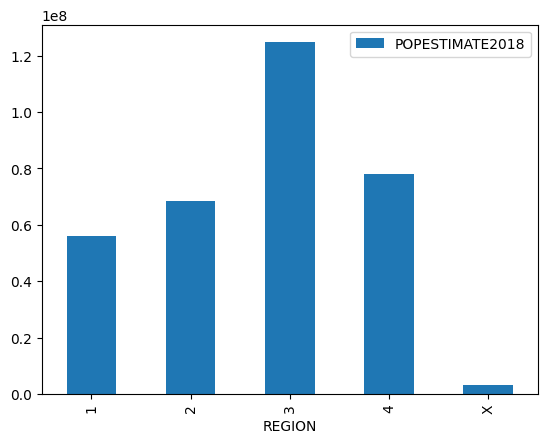

In [77]:
import matplotlib.pyplot as plot
regions_populations.plot(kind = 'bar', x = 'REGION', y = 'POPESTIMATE2018' )
plot.show()



##Q3. Parsing the JSON File (FHIR structure)

Q3. Parsing the JSON File (FHIR structure)

Using json module:

	1.	Load patient.json into a Python dictionary.

	2.	Extract and print:

	•	Patient’s full official name

	•	Gender and birth date

	•	Current address (city, state, postal code)
  
	3.	Count how many phone numbers the patient has, and list their types (e.g., work, mobile, home).

###1.  Load patient.json into a Python dictionary.

In [78]:
import json
from pathlib import Path
patient_file = '/content/patient.json'
patients = json.load(open(patient_file))
patients

{'resourceType': 'Patient',
 'id': 'example',
 'identifier': [{'use': 'usual',
   'type': {'coding': [{'system': 'http://terminology.hl7.org/CodeSystem/v2-0203',
      'code': 'MR'}]},
   'system': 'urn:oid:1.2.36.146.595.217.0.1',
   'value': '12345',
   'period': {'start': '2001-05-06'},
   'assigner': {'display': 'Acme Healthcare'}}],
 'active': True,
 'name': [{'use': 'official',
   'family': 'Chalmers',
   'given': ['Peter', 'James']},
  {'use': 'usual', 'given': ['Jim']},
  {'use': 'maiden',
   'family': 'Windsor',
   'given': ['Peter', 'James'],
   'period': {'end': '2002'}}],
 'telecom': [{'use': 'home'},
  {'system': 'phone', 'value': '(03) 5555 6473', 'use': 'work', 'rank': 1},
  {'system': 'phone', 'value': '(03) 3410 5613', 'use': 'mobile', 'rank': 2},
  {'system': 'phone',
   'value': '(03) 5555 8834',
   'use': 'old',
   'period': {'end': '2014'}}],
 'gender': 'male',
 'birthDate': '1974-12-25',
 '_birthDate': {'extension': [{'url': 'http://hl7.org/fhir/StructureDefinitio

In [147]:
print(json.dumps(patients,indent = 4))

{
    "resourceType": "Patient",
    "id": "example",
    "identifier": [
        {
            "use": "usual",
            "type": {
                "coding": [
                    {
                        "system": "http://terminology.hl7.org/CodeSystem/v2-0203",
                        "code": "MR"
                    }
                ]
            },
            "system": "urn:oid:1.2.36.146.595.217.0.1",
            "value": "12345",
            "period": {
                "start": "2001-05-06"
            },
            "assigner": {
                "display": "Acme Healthcare"
            }
        }
    ],
    "active": true,
    "name": [
        {
            "use": "official",
            "family": "Chalmers",
            "given": [
                "Peter",
                "James"
            ]
        },
        {
            "use": "usual",
            "given": [
                "Jim"
            ]
        },
        {
            "use": "maiden",
            "family": "

In [79]:
#lets confirm that the json file is madeup of a dictionary
print(type(patients))

<class 'dict'>


In [137]:
print(patients)

{'resourceType': 'Patient', 'id': 'example', 'identifier': [{'use': 'usual', 'type': {'coding': [{'system': 'http://terminology.hl7.org/CodeSystem/v2-0203', 'code': 'MR'}]}, 'system': 'urn:oid:1.2.36.146.595.217.0.1', 'value': '12345', 'period': {'start': '2001-05-06'}, 'assigner': {'display': 'Acme Healthcare'}}], 'active': True, 'name': [{'use': 'official', 'family': 'Chalmers', 'given': ['Peter', 'James']}, {'use': 'usual', 'given': ['Jim']}, {'use': 'maiden', 'family': 'Windsor', 'given': ['Peter', 'James'], 'period': {'end': '2002'}}], 'telecom': [{'use': 'home'}, {'system': 'phone', 'value': '(03) 5555 6473', 'use': 'work', 'rank': 1}, {'system': 'phone', 'value': '(03) 3410 5613', 'use': 'mobile', 'rank': 2}, {'system': 'phone', 'value': '(03) 5555 8834', 'use': 'old', 'period': {'end': '2014'}}], 'gender': 'male', 'birthDate': '1974-12-25', '_birthDate': {'extension': [{'url': 'http://hl7.org/fhir/StructureDefinition/patient-birthTime', 'valueDateTime': '1974-12-25T14:35:45-05:

#### 2A. Patient’s full official name

In [121]:
#where is the patient's name located in the dict?

patients['name']

[{'use': 'official', 'family': 'Chalmers', 'given': ['Peter', 'James']},
 {'use': 'usual', 'given': ['Jim']},
 {'use': 'maiden',
  'family': 'Windsor',
  'given': ['Peter', 'James'],
  'period': {'end': '2002'}}]

In [120]:
for name in patients['name']:
  first_name = name.get('given')
  last_name = name.get('family', 'none')
  print('Full Name:',first_name, last_name)

Full Name: ['Peter', 'James'] Chalmers
Full Name: ['Jim'] none
Full Name: ['Peter', 'James'] Windsor


#### 2B - Gender and birth date
 'gender': 'male',
 'birthDate': '1974-12-25',


In [144]:
print('Gender:',type(patients['gender']))
print('DOB:',type(patients['birthDate']))


Gender: <class 'str'>
DOB: <class 'str'>


In [171]:
#for gender in patients['contact']:
gender = patients.get('gender')
dob = patients.get('birthDate')
print('Patient Gender:',gender, '&' '', 'Birthdate:', dob)


Patient Gender: male & Birthdate: 1974-12-25


####  2C - Current address (city, state, postal code)

In [176]:
patient_address = patients.get('address')
patient_address

[{'use': 'home',
  'type': 'both',
  'text': '534 Erewhon St PeasantVille, Rainbow, Vic  3999',
  'line': ['534 Erewhon St'],
  'city': 'PleasantVille',
  'district': 'Rainbow',
  'state': 'Vic',
  'postalCode': '3999',
  'period': {'start': '1974-12-25'}}]

In [185]:
for address in patients['address']:
  city = address.get('city')
  state = address.get('state')
  zip = address.get('postalCode')
  print('Patient Address:',city,",",state,",",zip)

Patient Address: PleasantVille , Vic , 3999


#### 4. Count how many phone numbers the patient has, and list their types (e.g., work, mobile, home).

In [ ]:
"telecom": [
        {
            "use": "home"
        },
        {
            "system": "phone",
            "value": "(03) 5555 6473",
            "use": "work",
            "rank": 1
        },
        {
            "system": "phone",
            "value": "(03) 3410 5613",
            "use": "mobile",
            "rank": 2
        },
        {
            "system": "phone",
            "value": "(03) 5555 8834",
            "use": "old",
            "period": {
                "end": "2014"
            }
        }
    ],

In [197]:
import pandas as pd

telecom = pd.DataFrame(patients['telecom'])
telecom['value'].count()

np.int64(3)

In [198]:
telecom['use'].unique()

array(['home', 'work', 'mobile', 'old'], dtype=object)